#### Ocean Modelling: Exercise 6
- Modify the Euler-forward method implemented in the codes at the beginning of this section (either the python or matlab version) and change it into the Euler-backward method
- Compare the results for different values of ∆t and upload your code and results on the GitHub repository

In [2]:
import numpy as np
import matplotlib.pyplot as plt

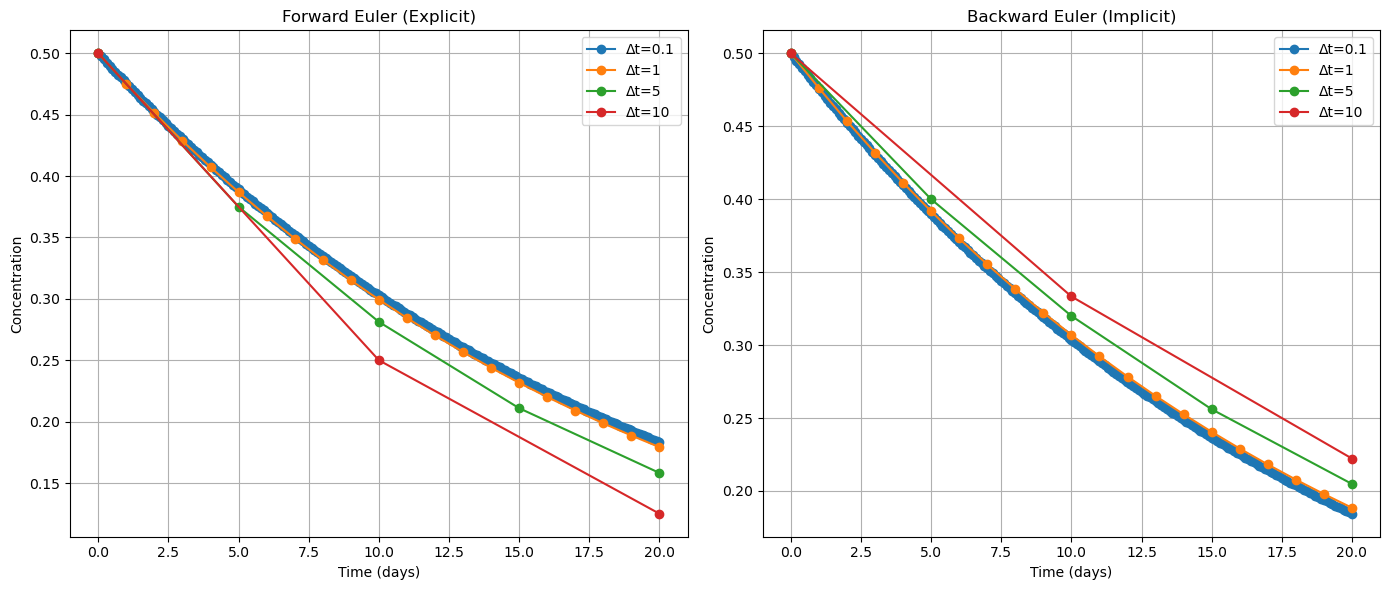

<Figure size 640x480 with 0 Axes>

In [3]:
# Compare Forward and Backward Euler Methods
import pylab as pl

# parameters
t0 = 0.0
tn = 20.0
kappa = 0.05
C0 = 0.5

# timesteps to test
dt_values = [0.1, 1, 5, 10]

# create figure
fig, ax = pl.subplots(1, 2, figsize=(14,6))

for dt in dt_values:

    # number of timesteps
    Ntot = int(pl.floor((tn - t0)/dt) + 1)
    # arrays
    t = pl.zeros(Ntot)

    C_forward = pl.zeros(Ntot)
    C_backward = pl.zeros(Ntot)

    # initial conditions
    t[0] = t0
    C_forward[0] = C0
    C_backward[0] = C0

    # time stepping loop
    for n in range(Ntot - 1):

        # Forward Euler (explicit)
        C_forward[n+1] = C_forward[n] * (1 - kappa*dt)

        # Backward Euler (implicit)
        C_backward[n+1] = C_backward[n] / (1 + kappa*dt)

        # update time
        t[n+1] = t[n] + dt

    # plot
    ax[0].plot(t, C_forward, marker='o', label=f'Δt={dt}')
    ax[1].plot(t, C_backward, marker='o', label=f'Δt={dt}')

# formatting Forward Euler plot
ax[0].set_title("Forward Euler (Explicit)")
ax[0].set_xlabel("Time (days)")
ax[0].set_ylabel("Concentration")
ax[0].grid(True)
ax[0].legend()

# formatting Backward Euler plot
ax[1].set_title("Backward Euler (Implicit)")
ax[1].set_xlabel("Time (days)")
ax[1].set_ylabel("Concentration")
ax[1].grid(True)
ax[1].legend()

pl.tight_layout()
pl.show()
plt.savefig('forward_backward_euler.png', dpi=300, bbox_inches='tight')